In [1]:
# =========================================================
# 2. Install and check COMPASS
# =========================================================
!pip install immuno-compass -U

In [3]:
# import os,sys
# os.environ["CUDA_VISIBLE_DEVICES"] = "7"  # Specify which GPU to use

In [4]:
import compass,random,torch,os
print("COMPASS VERSION:", compass.__version__)

/mnt/mamba_envs/envs/compass_tc2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


COMPASS VERSION: 2.5.3


In [5]:
# =========================================================
# 3. Define output directory
# =========================================================
save_dir = './compass_run/PT_v100'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [6]:
# =========================================================
# 4. Import core modules
# =========================================================
from compass import loadcompass
from compass import PreTrainer, FineTuner
from compass.tokenizer import CANCER_CODE,TOKENS_SHORT
from compass.utils import plot_performance, score2
import pandas as pd
import numpy as np

get_ipython().run_line_magic('matplotlib', 'inline')

In [7]:
# =========================================================
# 5. Data loading function
# =========================================================
_GLOBALS = {}

def load_tcga(path):
    """
    Load TCGA transcriptomic and label tables.
    Parameters
    ----------
    path : str
        Path to the folder containing 'TCGA.TPM.TABLE' and 
        'TCGA.PATIENT.PROCESSED.TABLE' files.

    Returns
    -------
    df_tpm : pd.DataFrame
        TPM-normalized gene expression matrix.
    df_label : pd.DataFrame
        Corresponding patient-level metadata.
    """
    if "df_tpm" not in _GLOBALS:
        _GLOBALS["df_tpm"] = pd.read_pickle(os.path.join(path, "TCGA.TPM.TABLE"))
        _GLOBALS["df_label"] = pd.read_pickle(os.path.join(path, "TCGA.PATIENT.TABLE"))
    return _GLOBALS["df_tpm"], _GLOBALS["df_label"]

In [8]:
# =========================================================
# 6. Prepare data for pretraining
# =========================================================
# Use a subset of genes for faster training (full TCGA gene set is large)

tcga_path = './data/TCGA/'

df_tpm, df_label = load_tcga(tcga_path)

# Encode cancer types numerically
df_cancer = df_label[["cancer_type"]]
dfcx = (
    df_cancer.cancer_type
    .apply(lambda x: x.replace("TCGA-", ""))
    .map(CANCER_CODE)
    .to_frame("cancer_code")
    .join(df_tpm)
)

# Stratified split by cancer type (90% train / 10% test)
test_idx = df_cancer.groupby("cancer_type").apply(
    lambda x: x.sample(frac=0.1, random_state=123).index.tolist()
).sum()
train_idx = df_cancer[~df_cancer.index.isin(test_idx)].index

dfcx_train, dfcx_test = dfcx.loc[train_idx], dfcx.loc[test_idx]
print("Training set:", dfcx_train.shape, "| Test set:", dfcx_test.shape)

Training set: (9166, 2476) | Test set: (1018, 2476)


Epoch: 1/20 - Train Loss: 0.8337 - Test Loss: 0.4217
Epoch: 2/20 - Train Loss: 0.4121 - Test Loss: 0.4066
Epoch: 3/20 - Train Loss: 0.4048 - Test Loss: 0.4026
Epoch: 4/20 - Train Loss: 0.4013 - Test Loss: 0.4002
Epoch: 5/20 - Train Loss: 0.3980 - Test Loss: 0.3960
Epoch: 6/20 - Train Loss: 0.3939 - Test Loss: 0.3913
Epoch: 7/20 - Train Loss: 0.3858 - Test Loss: 0.3780
Epoch: 8/20 - Train Loss: 0.3376 - Test Loss: 0.2526
Epoch: 9/20 - Train Loss: 0.2226 - Test Loss: 0.2124
Epoch: 10/20 - Train Loss: 0.2060 - Test Loss: 0.1926
Epoch: 11/20 - Train Loss: 0.1990 - Test Loss: 0.1971
Epoch: 12/20 - Train Loss: 0.1988 - Test Loss: 0.1899
Epoch: 13/20 - Train Loss: 0.1942 - Test Loss: 0.1894
Epoch: 14/20 - Train Loss: 0.2007 - Test Loss: 0.1959
Epoch: 15/20 - Train Loss: 0.1913 - Test Loss: 0.1911
Epoch: 16/20 - Train Loss: 0.1947 - Test Loss: 0.1972
Epoch: 17/20 - Train Loss: 0.1944 - Test Loss: 0.1912
Epoch: 18/20 - Train Loss: 0.1904 - Test Loss: 0.1961
Epoch: 19/20 - Train Loss: 0.1908 - T

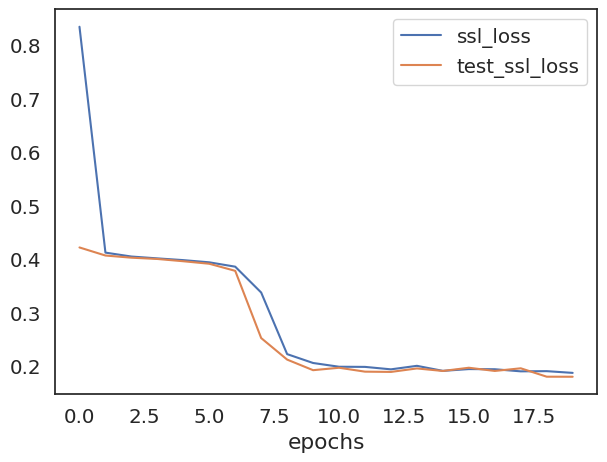

In [9]:
# =========================================================
# 7. Define training configuration and Run pretraining
# =========================================================

model_args = {
    'lr': 1e-4,              # Adjust to 1e-4 when using all genes
    'epochs': 20,
    'weight_decay': 1e-10,
    'batch_size': 128,      # Reduce if memory is limited
    'seed': 64,
    'patience': 10,
    'encoder_dropout':0,
    'encoder': 'performer',  # Use performer or transformer encoder for efficient attention
    'batch_correction': 0.6,
}

data_args = {
    'no_augment_prob': 0.2,  # Probability of skipping augmentation 0
    'mask_p_prob': 0.5,      # Probability of masking positive samples
    'jitter_p_std': 0.7,     # Additive noise for feature perturbation 0.8
    'mask_n_prob': 0.0,
    'mask_a_prob': 0.0,
    'jitter_a_std': 0.0,
    'jitter_n_std': 0.0,
}

pretrainer = PreTrainer(**model_args,  work_dir=save_dir)

pretrainer.train(
    dfcx_train=dfcx_train,
    dfcx_test=dfcx_test,
    **data_args)

# Save pretrained model checkpoint
pretrainer.save(f'{save_dir}/pretrainer.pt')
print("Pretraining completed. Model saved to:", 
      f'{save_dir}/pretrainer.pt')